# 1  Load the 'Mall Customers' dataset (or any small customer dataset) and apply the DBSCAN algorithm using scikit-learn to cluster users based on their annual income and spending score. Print the number of clusters found and the number of noise points detected.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN

In [7]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [9]:
dbscan = DBSCAN(eps=9.0, min_samples=5)
df['Cluster'] = dbscan.fit_predict(X)

In [10]:
clusters_found = len(set(df['Cluster'])) - (1 if -1 in df['Cluster'].values else 0)
noise_points = list(df['Cluster']).count(-1)

In [13]:
print(f"Clusters: {clusters_found}")
print(f"Noise: {noise_points}")

Clusters: 6
Noise: 23


# 2. Visualize the DBSCAN clustering results from your previous task using matplotlib — plot each cluster in a different color, and mark noise points in black. Add axis labels and a legend for clarity.

In [14]:
plt.figure(figsize=(8, 5))

core_points = df[df['Cluster'] != -1]
noise_points = df[df['Cluster'] == -1]

<Figure size 800x500 with 0 Axes>

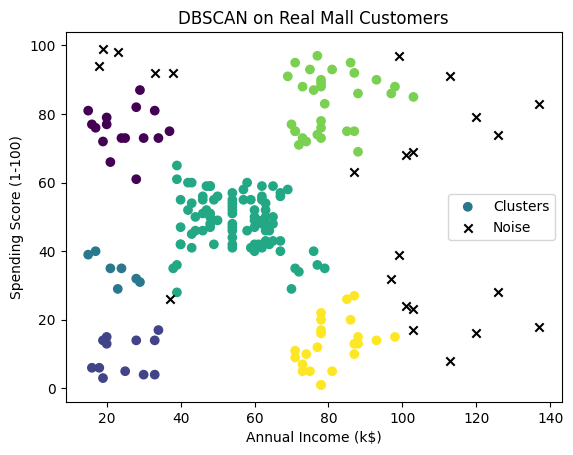

In [19]:
plt.scatter(core_points['Annual Income (k$)'], core_points['Spending Score (1-100)'], 
            c=core_points['Cluster'], cmap='viridis', label='Clusters')

plt.scatter(noise_points['Annual Income (k$)'], noise_points['Spending Score (1-100)'], 
            color='black', marker='x', label='Noise')

plt.title("DBSCAN on Real Mall Customers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

# 3. Change the DBSCAN parameters (eps and min_samples) to see how the number of clusters and noise points change. Write a short summary (3-4 lines) explaining how parameter choices affect the clustering outcome for your dataset.<br><br><em><strong>Hint:</strong> Try at least two different values for eps and min_samples, and compare results.</em>

In [20]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

db_strict = DBSCAN(eps=5.0, min_samples=8).fit_predict(X)

db_loose = DBSCAN(eps=15.0, min_samples=3).fit_predict(X)

print("Strict params (eps=5, min=8):", len(set(db_strict)) - 1, "clusters |", list(db_strict).count(-1), "noise points")
print("Loose params (eps=15, min=3):", len(set(db_loose)) - 1, "clusters |", list(db_loose).count(-1), "noise points")

Strict params (eps=5, min=8): 2 clusters | 120 noise points
Loose params (eps=15, min=3): 0 clusters | 0 noise points


When we decrease eps and increase min_samples (Strict), the algorithm forces most of the real-world mall customers into the "noise" category because they aren't packed closely enough. When we increase eps (Loose), it absorbs almost everyone into a few massive clusters and leaves almost zero noise points.

# 4. Compare DBSCAN and K-Means on the same dataset: run both algorithms, plot their cluster assignments side by side, and briefly note which method better handles outliers or oddly-shaped clusters.<br><br><em><strong>Constraint:</strong> Use the same features and number of clusters (for K-Means) as you observed with DBSCAN.</em>

In [25]:
from sklearn.cluster import KMeans

In [26]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
df['KMeans_Cluster'] = kmeans.fit_predict(df[['Annual Income (k$)', 'Spending Score (1-100)']])

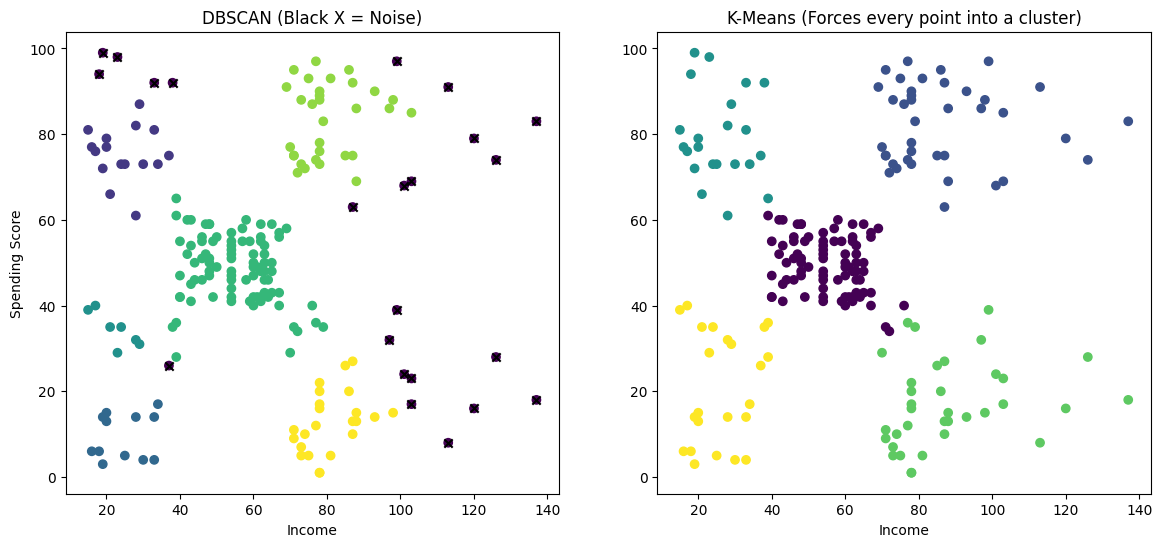

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'], cmap='viridis')
ax1.scatter(df[df['Cluster'] == -1]['Annual Income (k$)'], df[df['Cluster'] == -1]['Spending Score (1-100)'], color='black', marker='x')
ax1.set_title("DBSCAN (Black X = Noise)")
ax1.set_xlabel("Income")
ax1.set_ylabel("Spending Score")

ax2.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['KMeans_Cluster'], cmap='viridis')
ax2.set_title("K-Means (Forces every point into a cluster)")
ax2.set_xlabel("Income")

plt.show()

DBSCAN allows outlier customers to be flagged as noise (black Xs), leaving the core shopper groups pure. K-Means lacks a noise feature, so it forces those extreme outliers into the nearest cluster, which can warp the boundaries of our customer segments.

# 5. Pick a dataset with non-spherical clusters (e.g., make_moons or make_circles from sklearn.datasets), and use DBSCAN to cluster the data. Identify and print the indices of all points labeled as noise (outliers).

In [30]:
from sklearn.datasets import make_moons

In [41]:
X_moon, _ = make_moons(n_samples=250, noise=0.08, random_state=42)

In [42]:
db_moon = DBSCAN(eps=0.15, min_samples=5)
labels = db_moon.fit_predict(X_moon)

In [43]:
noise_indices = []
for i in range(len(labels)):
    if labels[i] == -1:
        noise_indices.append(i)

print(f"noise points: {len(noise_indices)}")
print(f"Indices of noise points:\n{noise_indices}")

noise points: 2
Indices of noise points:
[21, 45]
